In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler



In [2]:
#Load the dataset
data=pd.read_csv("CarPrice_Assignment.csv")
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
#DATA Preprocessing 
#Dropping unnesscary columns and handling categorial variables
data=data.drop(['CarName', 'car_ID'],axis=1)
data=pd.get_dummies(data,drop_first=True)

In [4]:
#Data preprossing and dropping unnecessary columns
data = data.drop(['CarName','car_ID'],axis=1,errors='ignore')
data = pd.get_dummies(data,drop_first=True)

In [5]:
#Spliting data
X = data.drop('price',axis=1)
y = data['price']

In [6]:
#Splitting dataset into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [7]:
#Creating the SGD Regressor model
sgd_model= SGDRegressor(max_iter=1000, tol=1e-3)


In [8]:
#Fitting the model on Training data
sgd_model.fit(X_train, y_train)

SGDRegressor()

In [9]:
#Making predictions
y_pred=sgd_model.predict(X_test)

In [10]:
#eVALUATING model performance
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)


In [11]:
#Print Evaluation metrics
print('Name: POOJA U')
print('Reg No: 212225230209')
print('Mean Squared Error:',mse)
print('R-squared Score:',r2)

Name: POOJA U
Reg No: 212225230209
Mean Squared Error: 1.4191102120076899e+32
R-squared Score: -1.7976158247259567e+24


In [12]:
#Print MODEL COEFFICIENTS
print("\nModel Coefficients:")
print("Coefficients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coefficients:
Coefficients: [ 6.34853974e+10 -1.73208231e+12 -1.31087604e+12 -3.30794115e+11
 -8.89677677e+11  2.44970439e+12  5.93419987e+12 -2.20448819e+10
 -3.06327772e+10 -3.47451197e+11  5.90407186e+12 -3.71497760e+12
 -6.12481025e+11 -6.07602277e+11  1.02769298e+10 -1.62048774e+10
  7.98843756e+10 -2.87453905e+08  1.11337377e+10 -8.53222081e+10
  4.70688643e+10  4.88305151e+10 -5.80910600e+09  1.42583586e+10
  8.51371941e+09 -4.13382794e+10 -1.50756077e+10  3.86062987e+09
  6.36498853e+10  8.85909091e+09  6.86110533e+09 -2.91794736e+10
 -5.63322726e+10  0.00000000e+00  1.62748249e+10  8.85909091e+09
 -8.52148359e+10  4.30629614e+09 -2.07750532e+10  1.88559751e+10
  5.99471872e+10  8.13680958e+09 -1.17082747e+10]
Intercept: [-1.05048595e+10]


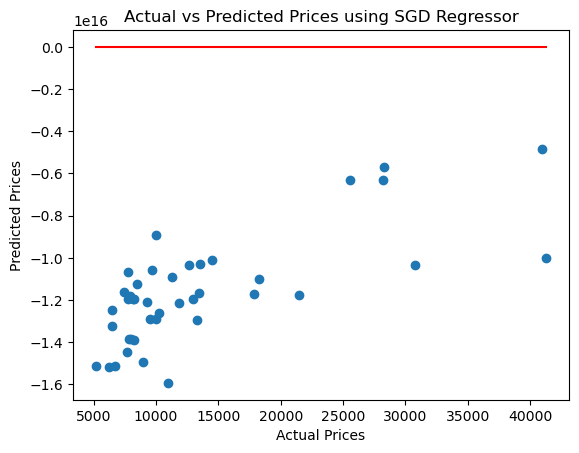

In [13]:
#Visualizing actual vs predicted prices
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test),max(y_test)], [min(y_test), max(y_test)], color='red')#Perfect Prediction line
plt.show()